# Harmony Annotation And Refinement

In this notebook, I review the Harmony-integrated object, assign broad cell-type labels using canonical marker genes, refine the ambiguous Harmony clusters, and save an annotated checkpoint for downstream analyses.

I keep the biological marker panels and cluster-to-label decisions exactly as defined in my earlier workflow, but I organise the notebook here so the annotation logic is easier to follow and review.


## 1. Imports And Project Setup

I start by loading only the libraries I need for annotation review, summary tables, and visual quality control.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc

sys.path.append(str(Path('../src').resolve()))
from c9_snrnaseq.io_utils import PROJECT_ROOT

RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load The Harmony-Integrated Object

I load the post-Harmony object that already contains the Harmony embedding, Harmony clustering, and sample metadata.


In [2]:
adata_hm = sc.read_h5ad(PROJECT_ROOT / 'data/processed/merged/adata_hm_after_harmony.h5ad')

print(adata_hm.shape)
print('Has leiden_harmony:', 'leiden_harmony' in adata_hm.obs.columns)
print('Has cell_class_major_harmony:', 'cell_class_major_harmony' in adata_hm.obs.columns)
print('Has cell_class_refined_harmony:', 'cell_class_refined_harmony' in adata_hm.obs.columns)


(89819, 2000)
Has leiden_harmony: True
Has cell_class_major_harmony: False
Has cell_class_refined_harmony: False


## 3. Define Small Helper Functions

I use a couple of small helpers so that I do not have to repeat the same marker filtering and composition-plot logic several times.


In [3]:
def keep_present_markers(marker_dict, var_names):
    marker_dict_present = {
        celltype: [gene for gene in genes if gene in var_names]
        for celltype, genes in marker_dict.items()
    }
    marker_dict_present = {
        celltype: genes
        for celltype, genes in marker_dict_present.items()
        if len(genes) > 0
    }
    return marker_dict_present


def show_crosstab(obs_df, row_col, col_col):
    table = pd.crosstab(obs_df[row_col], obs_df[col_col])
    display(table)
    return table


def plot_sample_composition(obs_df, group_col, title, figsize=(12, 6), rotation=45):
    plot_df = obs_df.dropna(subset=[group_col]).copy()
    plot_df['sample_display'] = plot_df['sample'].astype(str)

    group_sizes = plot_df[group_col].value_counts()
    group_order = group_sizes.index.tolist()
    x_labels = [f"{group} ({group_sizes[group]} cells)" for group in group_order]

    group_sample_pct = pd.crosstab(
        plot_df[group_col],
        plot_df['sample_display'],
        normalize='index'
    ).mul(100)
    group_sample_pct = group_sample_pct.loc[group_order]

    ax = group_sample_pct.plot(
        kind='bar',
        stacked=True,
        figsize=figsize,
        width=0.8,
    )

    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel('Per cent (%)')
    ax.set_xticklabels(x_labels, rotation=rotation, ha='right')
    ax.legend(title='Sample', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    return group_sample_pct


def plot_cluster_sample_composition(adata, cluster_col='leiden_harmony'):
    adata.obs['sample_display'] = adata.obs['sample'].astype(str)
    cluster_sizes = adata.obs[cluster_col].value_counts()
    cluster_order = sorted(cluster_sizes.index, key=lambda x: int(x) if str(x).isdigit() else str(x))

    if 'cell_class_major_harmony' in adata.obs.columns:
        cluster_major = (
            adata.obs.groupby(cluster_col)['cell_class_major_harmony']
            .agg(lambda x: x.value_counts().index[0] if len(x.dropna()) > 0 else 'Unknown')
        )
        x_labels = [
            f"{cluster} - {cluster_major.get(cluster, 'Unknown')} ({cluster_sizes[cluster]} cells)"
            for cluster in cluster_order
        ]
    else:
        x_labels = [f"{cluster} ({cluster_sizes[cluster]} cells)" for cluster in cluster_order]

    cluster_sample_pct = pd.crosstab(
        adata.obs[cluster_col],
        adata.obs['sample_display'],
        normalize='index'
    ).mul(100)
    cluster_sample_pct = cluster_sample_pct.loc[cluster_order]

    ax = cluster_sample_pct.plot(
        kind='bar',
        stacked=True,
        figsize=(18, 6),
        width=0.85,
    )

    ax.set_title('Motor Cortex - Sample per Harmony Cluster')
    ax.set_xlabel('Harmony Cluster')
    ax.set_ylabel('Per cent of cluster (%)')
    ax.set_xticklabels(x_labels, rotation=55, ha='right')
    ax.legend(title='Sample', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    return cluster_sample_pct


## 4. Review Broad Marker Panels Across Harmony Clusters

I define my broad canonical marker panels first, then filter them to genes that are actually present in the Harmony object.


In [4]:
marker_dict_broad = {
    'Excitatory_neurons': ['RORB', 'THEMIS', 'CUX2', 'TLE4', 'EYA4', 'SCN4B', 'NEFH'],
    'Inhibitory_neurons': ['GAD1', 'GAD2', 'PVALB', 'SST', 'VIP', 'RELN', 'LAMP5'],
    'Astrocytes': ['GFAP', 'AQP4', 'SLC1A2', 'SLC1A3', 'ATP1A2', 'CD44'],
    'Microglia': ['P2RY12', 'TYROBP', 'LST1', 'AIF1', 'C1QC', 'FCER1G'],
    'OPCs': ['PTPRZ1', 'VCAN', 'TNR', 'PDGFRA', 'CSPG4'],
    'Oligodendrocytes': ['CNP', 'PLP1', 'MBP', 'MOBP', 'SLC44A1', 'TF', 'ABCA2'],
    'Endothelial': ['CLDN5', 'PECAM1', 'FLT1', 'VWF', 'ABCB1'],
    'Vascular_mural_like': ['PDGFRB', 'RGS5', 'MCAM', 'CALD1', 'ACTA2', 'TAGLN', 'MYH11'],
}

marker_dict_broad_present = keep_present_markers(marker_dict_broad, adata_hm.var_names)
marker_dict_broad_present


{'Excitatory_neurons': ['RORB', 'EYA4', 'NEFH'],
 'Inhibitory_neurons': ['GAD1', 'GAD2', 'SST', 'VIP', 'RELN'],
 'Astrocytes': ['GFAP', 'AQP4', 'SLC1A2', 'SLC1A3', 'ATP1A2', 'CD44'],
 'Microglia': ['P2RY12', 'TYROBP', 'LST1', 'AIF1', 'C1QC', 'FCER1G'],
 'OPCs': ['PTPRZ1', 'VCAN', 'TNR'],
 'Endothelial': ['CLDN5', 'PECAM1', 'FLT1', 'VWF', 'ABCB1'],
 'Vascular_mural_like': ['PDGFRB', 'ACTA2']}

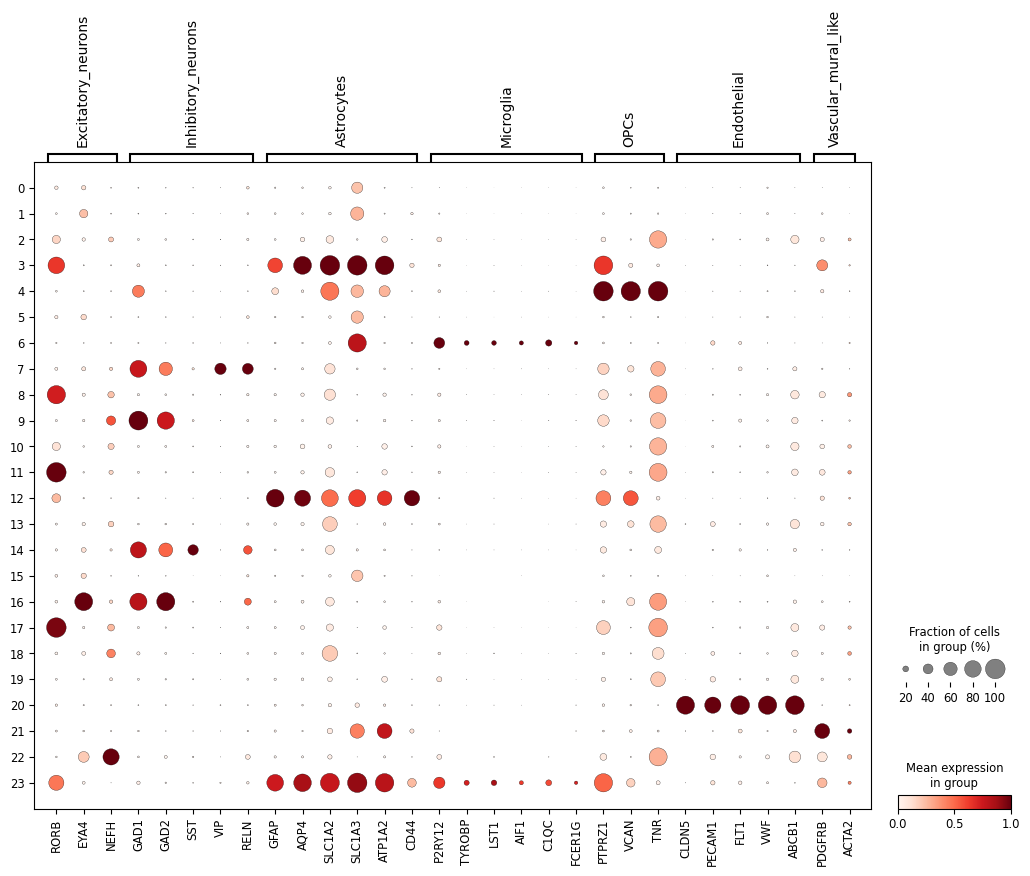

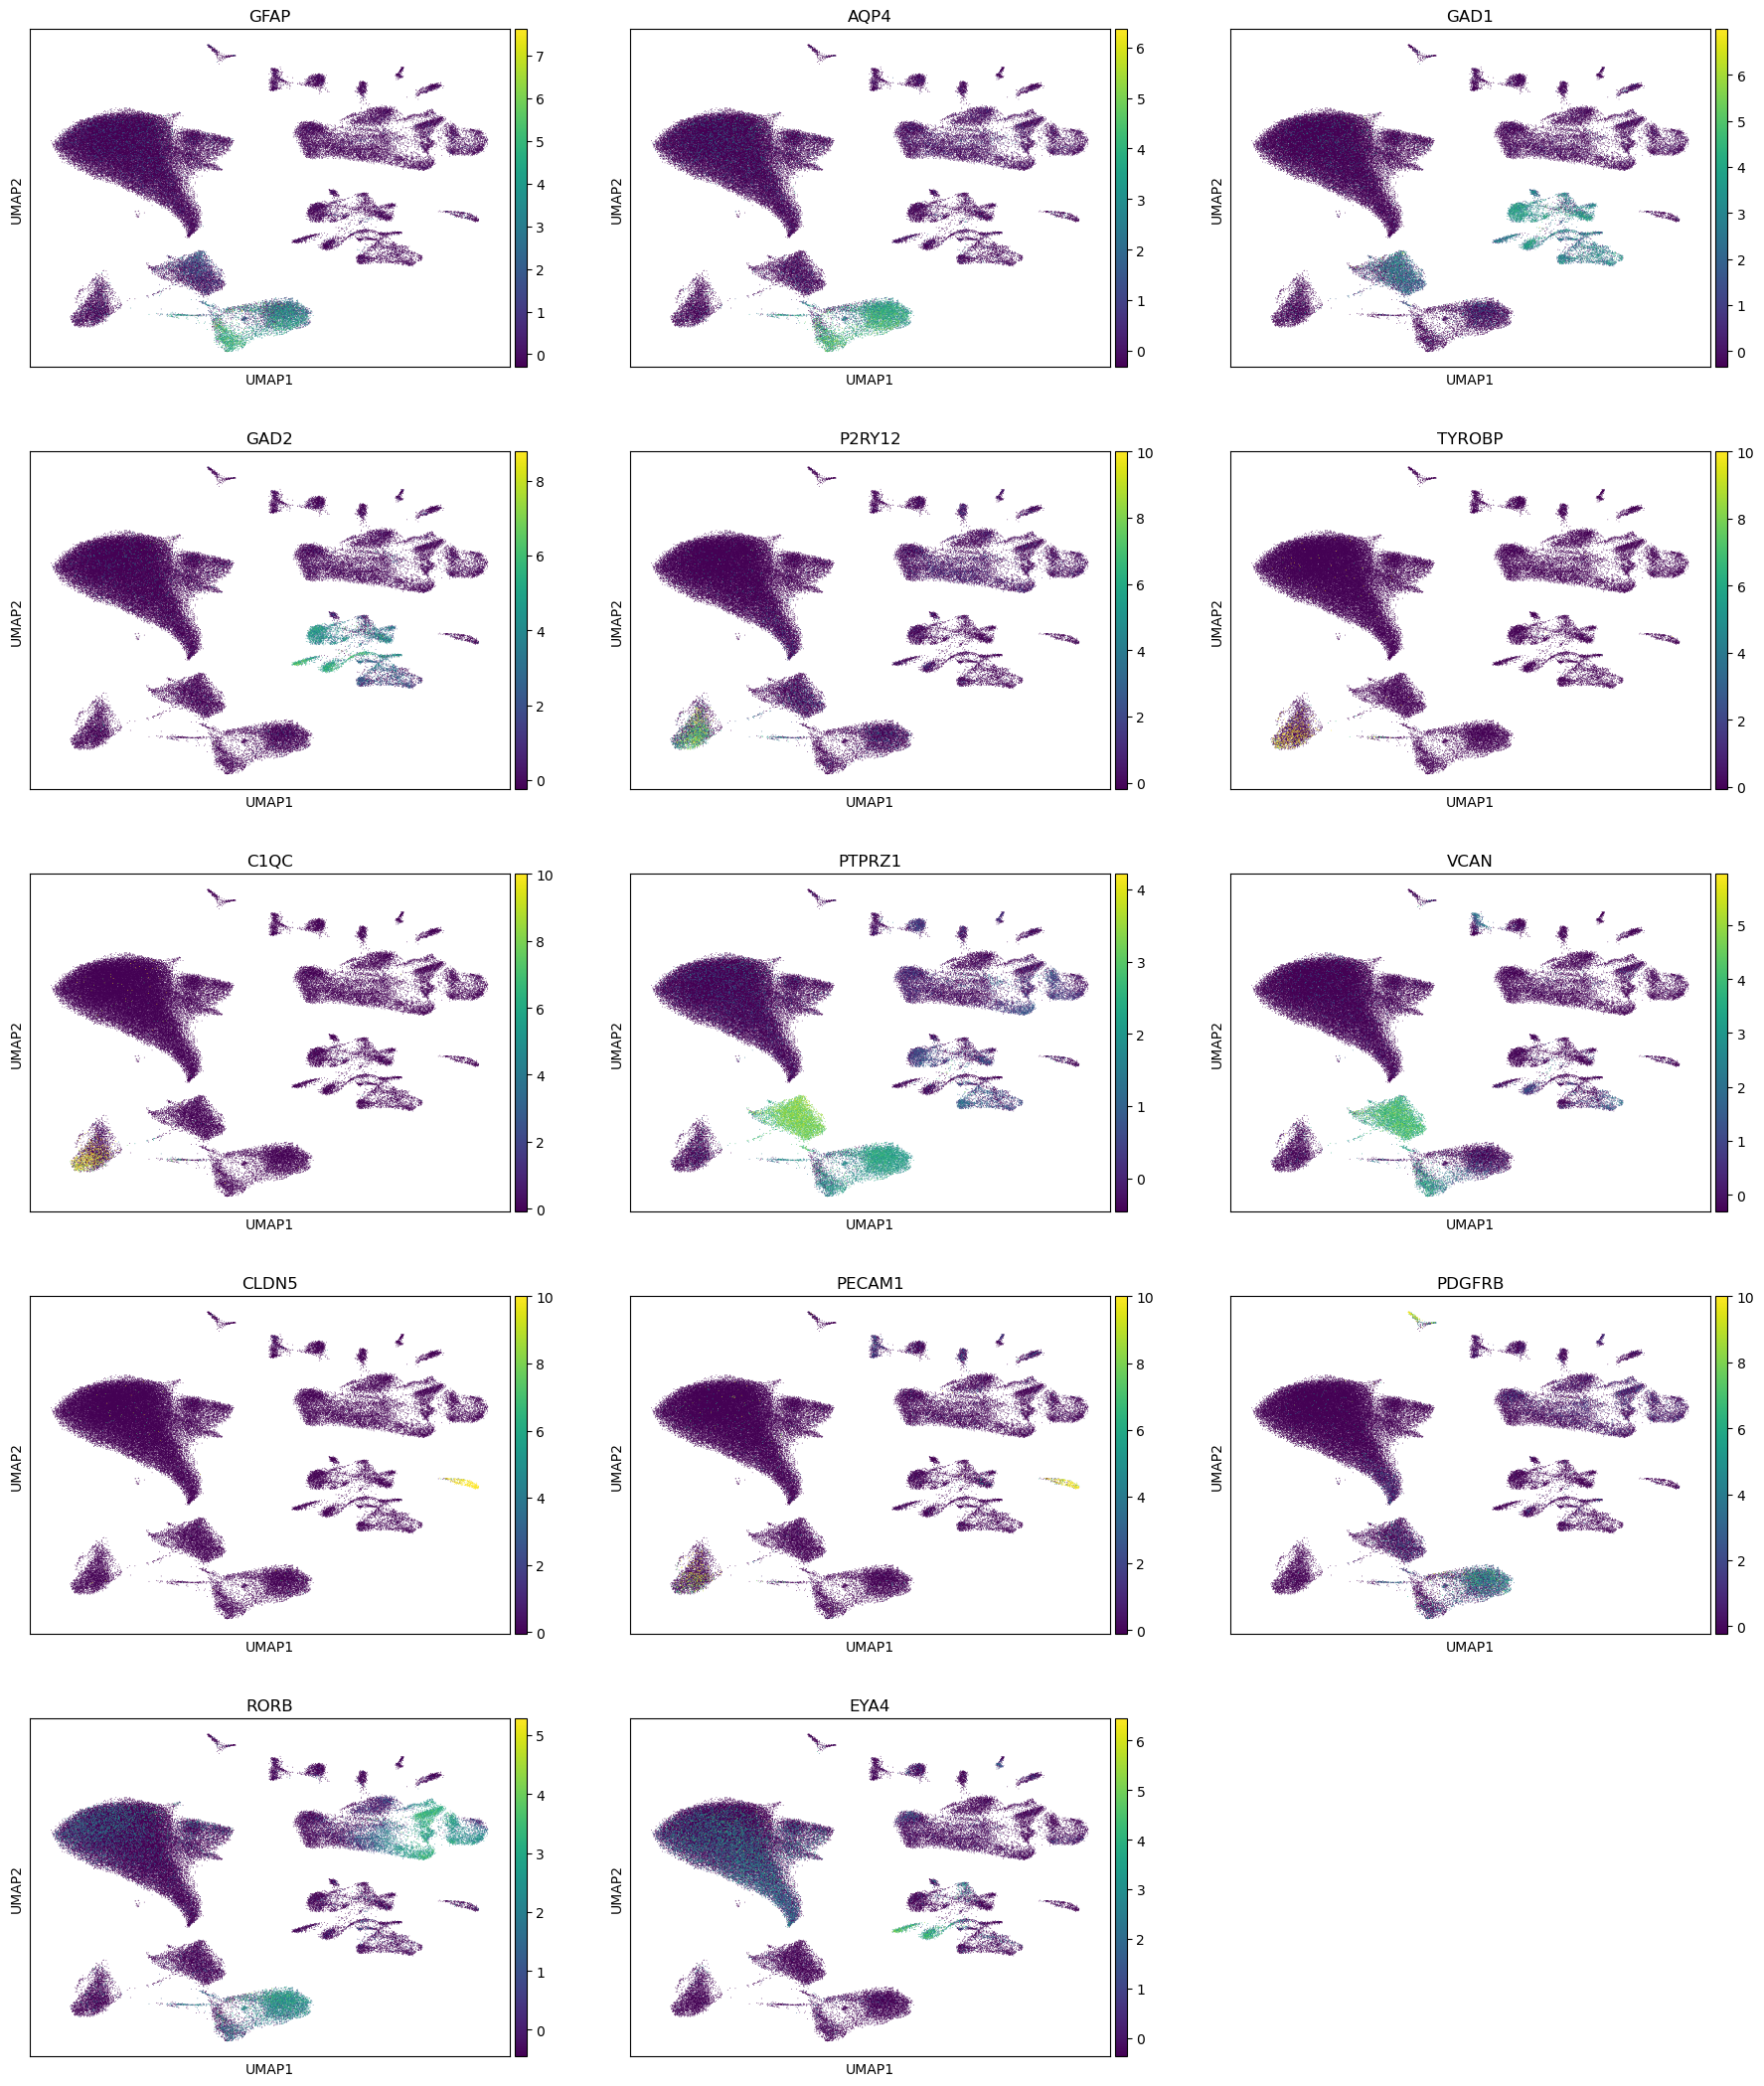

In [5]:
sc.pl.dotplot(
    adata_hm,
    marker_dict_broad_present,
    groupby='leiden_harmony',
    standard_scale='var',
)

umap_marker_panel = [
    gene for gene in [
        'GFAP', 'AQP4',
        'GAD1', 'GAD2',
        'P2RY12', 'TYROBP', 'C1QC',
        'PTPRZ1', 'VCAN',
        'CLDN5', 'PECAM1',
        'PDGFRB', 'RGS5',
        'RORB', 'THEMIS', 'EYA4',
    ]
    if gene in adata_hm.var_names
]

sc.pl.umap(adata_hm, color=umap_marker_panel, ncols=3)


## 5. Assign Broad Harmony Labels

I now apply the broad cluster-to-label mapping that I already established from the marker review above.


In [6]:
cluster_to_major_harmony = {
    '0': 'Unknown',
    '1': 'Unknown',
    '2': 'Excitatory_neurons',
    '3': 'Excitatory_neurons',
    '4': 'Astrocytes',
    '5': 'OPCs',
    '6': 'Microglia',
    '7': 'Microglia',
    '8': 'Inhibitory_neurons',
    '9': 'Excitatory_neurons',
    '10': 'Inhibitory_neurons',
    '11': 'Excitatory_neurons',
    '12': 'Excitatory_neurons',
    '13': 'Astrocytes',
    '14': 'Excitatory_neurons',
    '15': 'Inhibitory_neurons',
    '16': 'Unknown',
    '17': 'Inhibitory_neurons',
    '18': 'Excitatory_neurons',
    '19': 'Excitatory_neurons',
    '20': 'Endothelial',
    '21': 'Vascular_mural_like',
    '22': 'Excitatory_neurons',
    '23': 'Astrocytes',
}

adata_hm.obs['cell_class_major_harmony'] = (
    adata_hm.obs['leiden_harmony'].astype(str).map(cluster_to_major_harmony).astype('category')
)


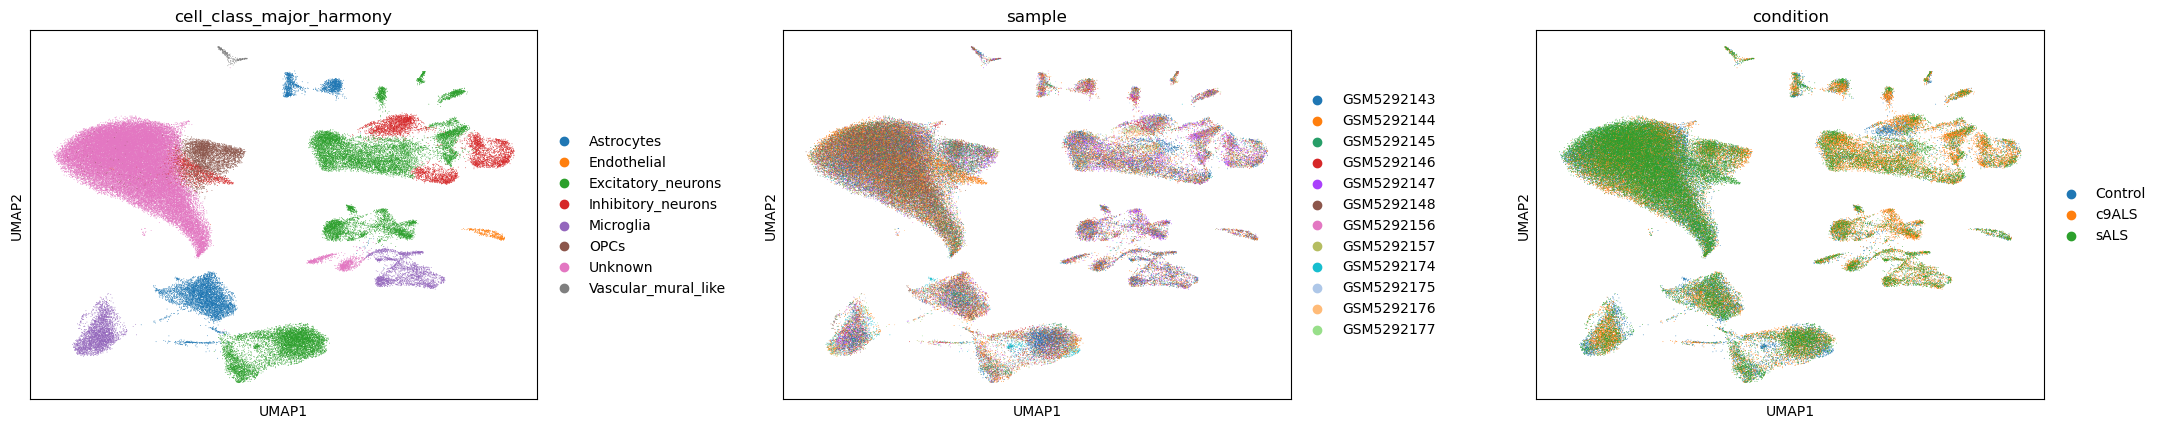

condition,Control,c9ALS,sALS
cell_class_major_harmony,,,
Astrocytes,2315,2368,2218
Endothelial,79,109,179
Excitatory_neurons,3994,9731,6291
Inhibitory_neurons,1311,2645,2040
Microglia,1309,2612,1906
OPCs,816,1712,1806
Unknown,11340,13594,21172
Vascular_mural_like,49,99,124


sample,GSM5292143,GSM5292144,GSM5292145,GSM5292146,GSM5292147,GSM5292148,GSM5292156,GSM5292157,GSM5292174,GSM5292175,GSM5292176,GSM5292177
cell_class_major_harmony,,,,,,,,,,,,
Astrocytes,528,701,314,725,663,675,480,500,459,532,970,354
Endothelial,39,71,2,36,38,67,16,19,16,46,7,10
Excitatory_neurons,2919,1805,341,2335,3112,1226,1649,2635,1269,1281,784,660
Inhibitory_neurons,553,1248,62,793,833,177,365,654,408,298,368,237
Microglia,880,537,188,757,883,301,385,587,499,295,285,230
OPCs,125,291,769,370,716,621,245,381,334,336,89,57
Unknown,3573,7707,3536,3703,4050,6356,2971,2870,2879,3474,3558,1429
Vascular_mural_like,43,24,7,26,38,50,24,11,14,18,6,11


sample,GSM5292143,GSM5292144,GSM5292145,GSM5292146,GSM5292147,GSM5292148,GSM5292156,GSM5292157,GSM5292174,GSM5292175,GSM5292176,GSM5292177
cell_class_major_harmony,,,,,,,,,,,,
Astrocytes,528,701,314,725,663,675,480,500,459,532,970,354
Endothelial,39,71,2,36,38,67,16,19,16,46,7,10
Excitatory_neurons,2919,1805,341,2335,3112,1226,1649,2635,1269,1281,784,660
Inhibitory_neurons,553,1248,62,793,833,177,365,654,408,298,368,237
Microglia,880,537,188,757,883,301,385,587,499,295,285,230
OPCs,125,291,769,370,716,621,245,381,334,336,89,57
Unknown,3573,7707,3536,3703,4050,6356,2971,2870,2879,3474,3558,1429
Vascular_mural_like,43,24,7,26,38,50,24,11,14,18,6,11


In [7]:
sc.pl.umap(
    adata_hm,
    color=['cell_class_major_harmony', 'sample', 'condition'],
    wspace=0.35,
)

show_crosstab(adata_hm.obs, 'cell_class_major_harmony', 'condition')
show_crosstab(adata_hm.obs, 'cell_class_major_harmony', 'sample')


## 6. Refine The Ambiguous Harmony Clusters

I focus next on the clusters that were still ambiguous after the broad pass and inspect them with a more targeted marker panel.


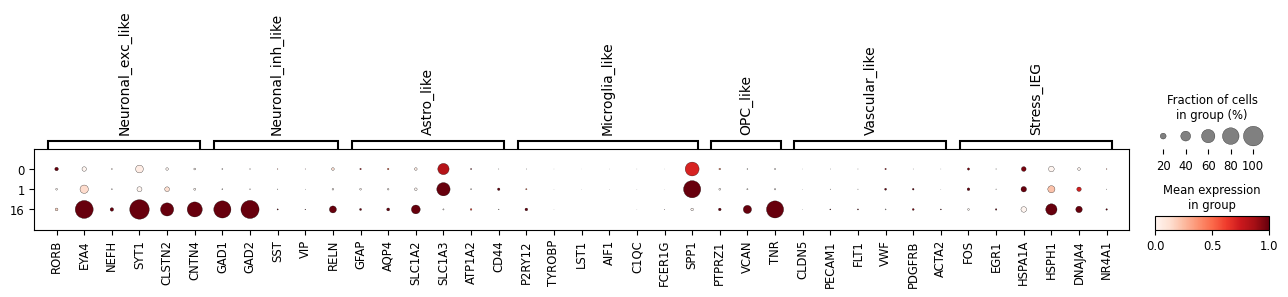

In [8]:
unknown_refine_markers = {
    'Neuronal_exc_like': ['RORB', 'THEMIS', 'EYA4', 'NEFH', 'SCN4B', 'CUX2', 'TLE4', 'SYT1', 'CLSTN2', 'CNTN4'],
    'Neuronal_inh_like': ['GAD1', 'GAD2', 'SST', 'VIP', 'RELN', 'PVALB', 'LAMP5'],
    'Astro_like': ['GFAP', 'AQP4', 'SLC1A2', 'SLC1A3', 'ATP1A2', 'CD44'],
    'Microglia_like': ['P2RY12', 'TYROBP', 'LST1', 'AIF1', 'C1QC', 'FCER1G', 'SPP1'],
    'OPC_like': ['PTPRZ1', 'VCAN', 'TNR', 'PDGFRA', 'CSPG4'],
    'Vascular_like': ['CLDN5', 'PECAM1', 'FLT1', 'VWF', 'PDGFRB', 'RGS5', 'ACTA2'],
    'Stress_IEG': ['FOS', 'EGR1', 'HSPA1A', 'HSPH1', 'DNAJA4', 'NR4A1'],
}
unknown_refine_markers = keep_present_markers(unknown_refine_markers, adata_hm.var_names)

unknown_clusters = ['0', '1', '16']
sc.pl.dotplot(
    adata_hm[adata_hm.obs['leiden_harmony'].isin(unknown_clusters)].copy(),
    unknown_refine_markers,
    groupby='leiden_harmony',
    standard_scale='var',
)


## 7. Assign Refined Harmony Labels And Collapse Back To Broad Labels

I keep the refined labels for interpretation, but I also collapse them back to a broad label set for downstream pseudobulk and differential expression analyses.


In [9]:
cluster_to_refined_harmony = {
    '0': 'Unknown_neuronal_like',
    '1': 'Microglia_reactive_like',
    '2': 'Excitatory_neurons',
    '3': 'Excitatory_neurons',
    '4': 'Astrocytes',
    '5': 'OPCs',
    '6': 'Microglia',
    '7': 'Microglia',
    '8': 'Inhibitory_neurons',
    '9': 'Excitatory_neurons',
    '10': 'Inhibitory_neurons',
    '11': 'Excitatory_neurons',
    '12': 'Excitatory_neurons',
    '13': 'Astrocytes',
    '14': 'Excitatory_neurons',
    '15': 'Inhibitory_neurons',
    '16': 'Stress_IEG',
    '17': 'Inhibitory_neurons',
    '18': 'Excitatory_neurons',
    '19': 'Excitatory_neurons',
    '20': 'Endothelial',
    '21': 'Vascular_mural_like',
    '22': 'Excitatory_neurons',
    '23': 'Astrocytes',
}

adata_hm.obs['cell_class_refined_harmony'] = (
    adata_hm.obs['leiden_harmony'].astype(str).map(cluster_to_refined_harmony).astype('category')
)

collapse_to_broad = {
    'Unknown_neuronal_like': 'Unknown',
    'Microglia_reactive_like': 'Microglia',
    'Stress_IEG': 'Unknown',
}

adata_hm.obs['cell_class_major_harmony'] = (
    adata_hm.obs['cell_class_refined_harmony']
    .astype(str)
    .replace(collapse_to_broad)
    .astype('category')
)


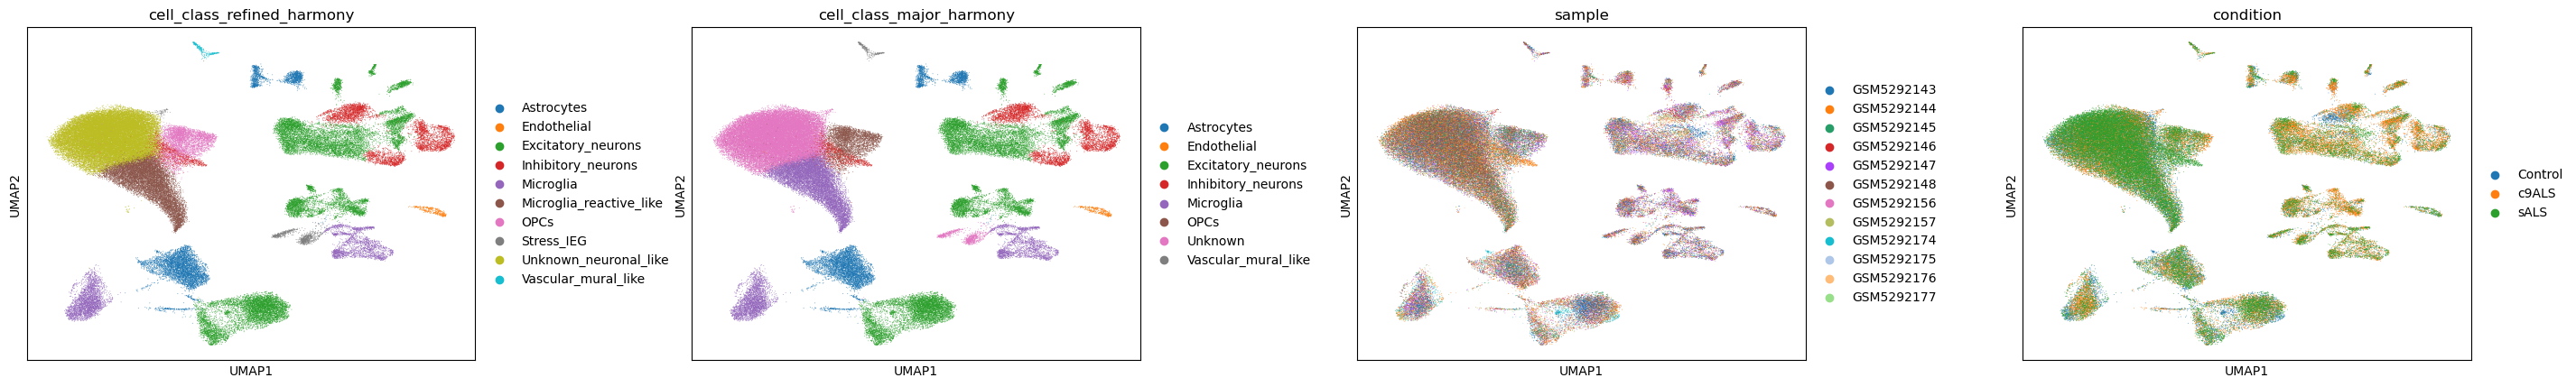

condition,Control,c9ALS,sALS
cell_class_refined_harmony,,,
Astrocytes,2315,2368,2218
Endothelial,79,109,179
Excitatory_neurons,3994,9731,6291
Inhibitory_neurons,1311,2645,2040
Microglia,1309,2612,1906
Microglia_reactive_like,3197,3219,5931
OPCs,816,1712,1806
Stress_IEG,219,491,367
Unknown_neuronal_like,7924,9884,14874


sample,GSM5292143,GSM5292144,GSM5292145,GSM5292146,GSM5292147,GSM5292148,GSM5292156,GSM5292157,GSM5292174,GSM5292175,GSM5292176,GSM5292177
cell_class_refined_harmony,,,,,,,,,,,,
Astrocytes,528,701,314,725,663,675,480,500,459,532,970,354
Endothelial,39,71,2,36,38,67,16,19,16,46,7,10
Excitatory_neurons,2919,1805,341,2335,3112,1226,1649,2635,1269,1281,784,660
Inhibitory_neurons,553,1248,62,793,833,177,365,654,408,298,368,237
Microglia,880,537,188,757,883,301,385,587,499,295,285,230
Microglia_reactive_like,563,2166,1289,751,770,1913,989,709,692,1045,1039,421
OPCs,125,291,769,370,716,621,245,381,334,336,89,57
Stress_IEG,148,127,15,168,150,77,69,104,53,48,100,18
Unknown_neuronal_like,2862,5414,2232,2784,3130,4366,1913,2057,2134,2381,2419,990


sample,GSM5292143,GSM5292144,GSM5292145,GSM5292146,GSM5292147,GSM5292148,GSM5292156,GSM5292157,GSM5292174,GSM5292175,GSM5292176,GSM5292177
cell_class_refined_harmony,,,,,,,,,,,,
Astrocytes,528,701,314,725,663,675,480,500,459,532,970,354
Endothelial,39,71,2,36,38,67,16,19,16,46,7,10
Excitatory_neurons,2919,1805,341,2335,3112,1226,1649,2635,1269,1281,784,660
Inhibitory_neurons,553,1248,62,793,833,177,365,654,408,298,368,237
Microglia,880,537,188,757,883,301,385,587,499,295,285,230
Microglia_reactive_like,563,2166,1289,751,770,1913,989,709,692,1045,1039,421
OPCs,125,291,769,370,716,621,245,381,334,336,89,57
Stress_IEG,148,127,15,168,150,77,69,104,53,48,100,18
Unknown_neuronal_like,2862,5414,2232,2784,3130,4366,1913,2057,2134,2381,2419,990


In [10]:
sc.pl.umap(
    adata_hm,
    color=['cell_class_refined_harmony', 'cell_class_major_harmony', 'sample', 'condition'],
    wspace=0.35,
)

show_crosstab(adata_hm.obs, 'cell_class_refined_harmony', 'condition')
show_crosstab(adata_hm.obs, 'cell_class_refined_harmony', 'sample')


## 8. Save The Annotated Harmony Checkpoint

I save the refined annotation object here so I can reuse it in later notebooks without repeating the annotation step.


In [ ]:
hm_annot_ckpt = PROJECT_ROOT / 'data/processed/merged/adata_hm_annotated.h5ad'
hm_annot_ckpt.parent.mkdir(parents=True, exist_ok=True)

adata_hm.write_h5ad(hm_annot_ckpt)

print(f'Saved annotated Harmony object to: {hm_annot_ckpt}')
print(adata_hm.shape)
print('Has cell_class_major_harmony:', 'cell_class_major_harmony' in adata_hm.obs.columns)
print('Has cell_class_refined_harmony:', 'cell_class_refined_harmony' in adata_hm.obs.columns)


## 9. Check Sample Composition Across Clusters And Broad Cell Types

As a final quality-control step, I check how strongly each Harmony cluster and each broad cell type is represented across samples.


/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_8824/3379387354.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(cluster_col)['cell_class_major_harmony']


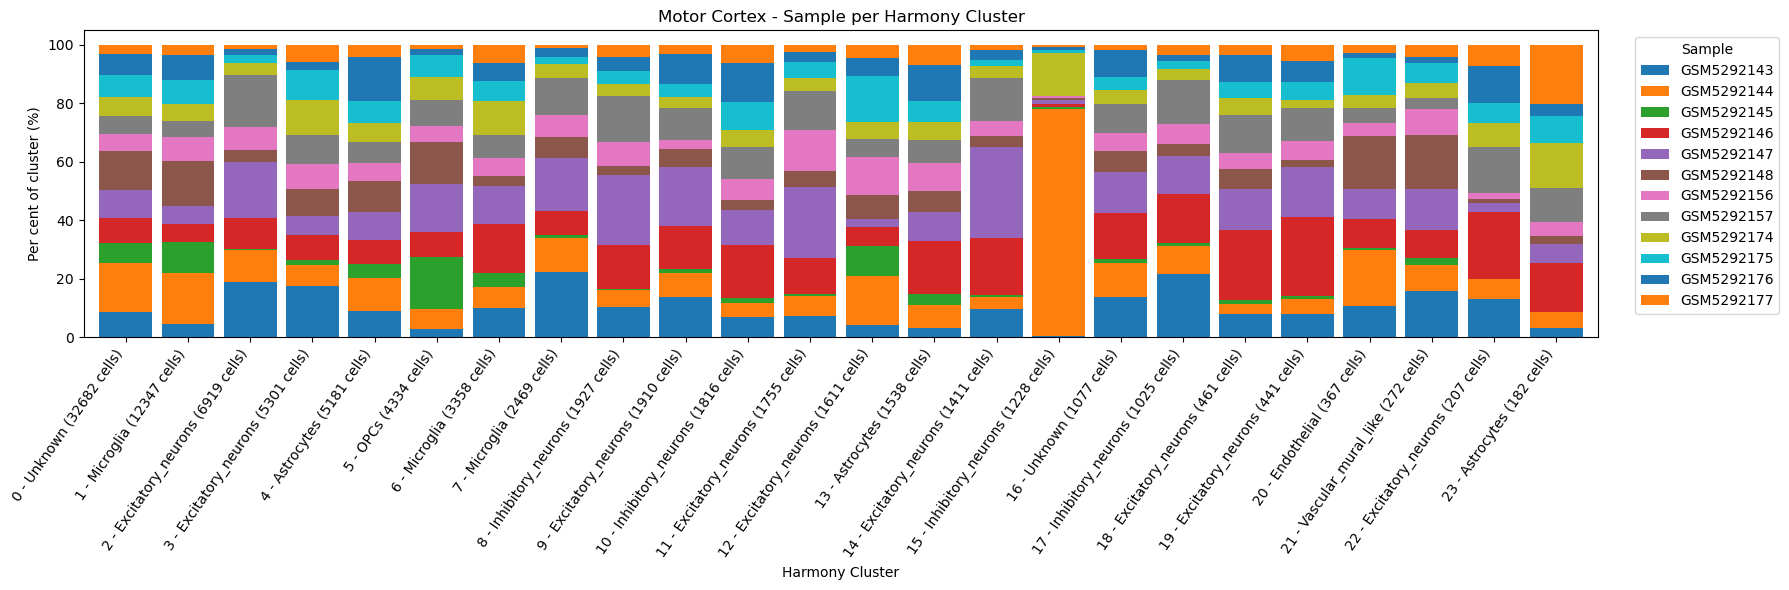

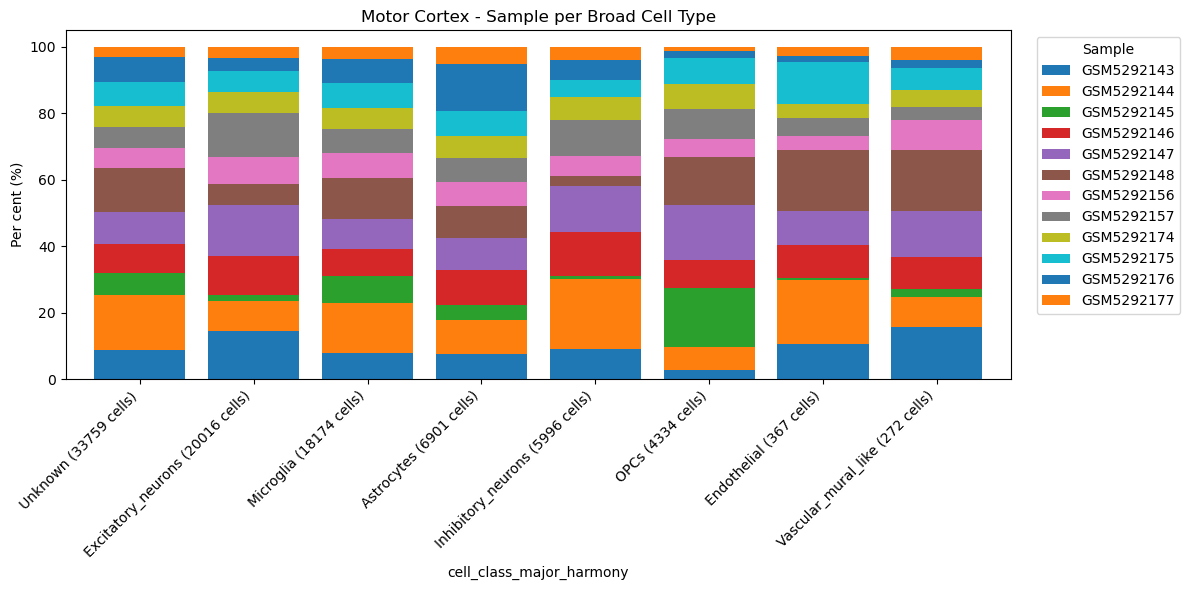

In [11]:
cluster_sample_pct = plot_cluster_sample_composition(adata_hm)
celltype_sample_pct = plot_sample_composition(
    adata_hm.obs,
    group_col='cell_class_major_harmony',
    title='Motor Cortex - Sample per Broad Cell Type',
    figsize=(12, 6),
    rotation=45,
)
